# 激活函数
- Sigmoid函数：将输入压缩到(0, 1)区间内，输出值可直接映射为概率，常用于二分类问题的输出层。但存在梯度消失和输出非零中心的问题。
- Tanh函数：将输入压缩到(-1, 1)区间内，输出为零中心，解决了Sigmoid函数的非零中心问题，但仍然存在梯度消失的问题。
- ReLU函数：当输入大于0时，输出等于输入；当输入小于等于0时，输出为0。ReLU函数计算简单，且能有效缓解梯度消失问题，是目前最常用的激活函数之一。
- Leaky ReLU函数：为了解决ReLU函数在输入小于0时梯度为0的问题，Leaky ReLU在输入小于0时引入了一个小的斜率，使得梯度不为0。
- ELU函数：结合了ReLU和Leaky ReLU的优点，在输入大于0时表现与ReLU相同，在输入小于0时引入了一个指数函数，使得输出更加平滑。
- Swish函数：一种自门控激活函数，形式为 f(x) = x * sigmoid(βx)，在某些任务中表现优于ReLU。

| 激活函数           | 输出范围   | 零中心化 | 主要优缺点             |
| -------------- | ------ | ---- | ----------------- |
| **Sigmoid**    | (0,1)  | ❌    | 易梯度消失，适合概率输出      |
| **Tanh**       | (-1,1) | ✅    | 比Sigmoid强，但仍会梯度消失 |
| **ReLU**       | \[0,∞) | ❌    | 计算快，简单，但会"神经元死亡"  |
| **Leaky ReLU** | (-∞,∞) | ❌    | 解决死亡问题，负区间有小斜率    |
| **ELU**        | (-α,∞) | 近似✅  | 平滑负值，收敛更快         |
| **Swish**      | (-∞,∞) | ❌    | 自门控机制，非单调，现代网络常用  |

使用建议
- 隐藏层默认首选 ReLU 或 Leaky ReLU
- 需要平滑输出时考虑 ELU 或 Swish
- 输出层二分类用 Sigmoid，多分类配合Softmax
- 现代Transformer架构中 Swish (SiLU) 表现优异

# sigmoid

Sigmoid函数是一种在机器学习和神经网络中广泛使用的激活函数，其核心作用是将任意实数输入压缩到(0, 1)区间内，输出值可直接映射为概率，这也是其在二分类任务中广泛应用的核心原因。

Sigmoid函数的精确数学公式如下：
$σ(x)= \frac{1}{1 + e^{-x}}$

- x 为函数输入，可取值为任意实数（定义域为（-∞，+∞）
- e 为自然常数（约等于2.71828）
- σ(x) 为函数输出，值域固定为（0,1）

从公式不难看出，Sigmoid函数的输出具有“两极收敛”特性：
- 当输入x --> +∞时，$e^{-x}$ --> 0 ,输出趋近于1
- 当输入x --> -∞时，$e^{-x}$ --> +∞,输出趋近于0
- 当出入x = 0 时，输出恰好为0.5

Sigmoid函数在神经网络中常被用作激活函数，将变量映射到0,1之间，适用于二分类问题。其优点包括平滑、易于计算，但缺点是当输入绝对值较大时，导数趋近于0，可能导致梯度消失问题。

# Tanh

Tanh（双曲正切函数）是深度学习和神经网络中非常重要的一种激活函数。
它与 Sigmoid 函数非常相似，但输出范围不同，这使得它在很多场景下比 Sigmoid 表现更好。

## 数学公式与图形
Tanh 函数的数学表达式如下：

$ tanh(x) = \frac{e^x -e^{-x}}{e^x + e^{-x}} $ 

或者，它也可以通过 Sigmoid 函数来表示：

$tanh(x) = 2 * σ(2x) - 1 $

其中σ(x) 是sigmoid函数

## 核心特性
- 输入范围：（-∞,+∞）
- 输出范围：（-1,1）

从图形上看，Tanh 函数的曲线呈“S”形，与 Sigmoid 类似，但它是以原点为中心对称的。

- 当 x = 0 时，tanh(0)
- 当 x趋向于正无穷时，输出趋向于1
- 当 x趋向于负无穷时，输出趋向于-1

## 为什么 Tanh 比 Sigmoid 好？（零中心化）
这是 Tanh 最大的优势。我们将其与 Sigmoid 进行对比：

| 特性 | Sigmoid | Tanh |
| :--- | :--- | :--- |
| 输出范围 |  $ (0, 1) $  |  $ (-1, 1) $  |
| 中心点 | 输出非零中心（偏向正数） | 零中心化 |
| 梯度消失 | 严重（最大导数为 0.25） | 依然存在（最大导数为 1.0） |

### 解释“零中心化”的重要性：
在神经网络中，如果上一层神经元的输出全是正数（例如 Sigmoid 输出都在 0 到 1 之间），那么下一层权重的梯度要么全为正，要么全为负（取决于损失函数的梯度）。这会导致权重更新时只能“曲折前进”（锯齿状更新），收敛速度变慢。

而 Tanh 的输出包含正数和负数，平均值接近 0。这使得下一层的权重梯度有正有负，更新方向更灵活，收敛速度通常比 Sigmoid 更快。

## 缺点：梯度消失与计算复杂度
尽管 Tanh 优于 Sigmoid，但它仍然存在一些问题：

1. 梯度消失（Vanishing Gradient）：
    当输入x的绝对值很大时（例如|x| > 3），Tanh曲线变得非常平缓，导致导数趋近于0
    - 导数公式：$  tanh`(x) = 1 - tanh^2(x) $
    - 当tanh(x) ≈±1师，tanh`(x) ≈ 0
    - 在深层网络中，反向传播时梯度会因为连乘趋近于 0，导致网络底层的权重几乎无法更新。
2. 计算复杂度：
    相比于 ReLU 等简单函数，Tanh 涉及指数运算，计算成本相对较高。
    
## 现代应用中的地位

虽然在现代深度学习中，ReLU 及其变体（如 Leaky ReLU, GELU）已经成为了隐藏层的默认选择（因为它们能有效缓解梯度消失且计算极快），但 Tanh 依然在某些领域有重要应用：

- 循环神经网络（RNN）：在很多经典的 RNN 结构（如 LSTM）中，Tanh 仍然被用作门控机制中的激活函数，因为它能将数值压缩到 -1 到 1 之间，有助于控制记忆单元的状态。
- 生成对抗网络（GAN）：在生成器的最后一层，有时会使用 Tanh 将输出像素值映射到 [−1,1] 范围（通常配合输入数据也归一化到该范围）。
- 多层感知机（MLP）：在一些较浅的网络或特定任务中，Tanh 依然是一个稳健的选择。

## 总结
Tanh 是一个比 Sigmoid 更优秀的“平滑”激活函数，因为它解决了输出非零中心的问题，加速了收敛。然而，由于它仍然存在梯度消失问题，它在深层前馈网络中已逐渐被 ReLU 系列取代，但在循环网络和特定生成模型中依然占有一席之地。

# relu

ReLU（Rectified Linear Unit，修正线性单元）是目前深度学习中最常用、最基础的激活函数之一。它以其简单、高效和出色的性能，成为了现代神经网络架构（如CNN、Transformer等）的默认选择。

## 数学公式与图形
ReLU 的数学定义非常简单：
f(x)  = max(0,x)

## 核心特性
- 输入范围：$（-∞，+∞）$
- 输出范围：$ [0,+∞) $ 
- 行为:
    - 当输入x>0时，输出等于输入
    - 当输入x≤0时，输出为0
    
从图形上看，ReLU 是一条折线：

    - 在 x>0 的区域是一条斜率为 1 的直线，
    - 在 x≤0 的区域是一条位于 y=0 的水平线 
    
    
## 为什么 ReLU 如此流行？
相比于早期的 Sigmoid 和 Tanh，ReLU 拥有以下显著优势：

1. 缓解梯度消失问题（Vanishing Gradient）
这是 ReLU 最大的贡献。在深度网络中，Sigmoid 和 Tanh 在输入绝对值较大时，导数会趋近于 0，导致梯度在反向传播时几乎消失，网络难以训练。

- ReLU的导数：
    - 当 x > 0 时，f`(x) = 1
    - 当 x < 0 时，f`(x) = 0
    - 当 x = 0 时，导数未定义（但在实际计算中通常设为0或1）
                
- 因为正数区域的梯度恒为1，梯度可以畅通无阻的向后传播，极大地缓解了深层网络的训练难题。

2. 计算简单高效

ReLU 仅涉及简单的阈值判断（max(0, x)），没有复杂的指数运算（如 Sigmoid 和 Tanh）。这使得前向传播和反向传播的计算速度非常快，且对内存占用极低。

3. 诱导稀疏性

当输入为负数时，ReLU 的输出为 0。这意味着在神经网络中，一部分神经元会被“关闭”。
- 优点： 这种稀疏性使得网络结构更接近生物神经网络，减少了特征之间的冗余和耦合，有助于提高模型的泛化能力。

## ReLU 的缺点与改进版本
尽管 ReLU 优势明显，但它并非完美，主要存在以下两个问题：

1. 神经元死亡（Dead Neurons / Dying ReLU）
这是 ReLU 最致命的缺陷。如果一个神经元的权重更新导致其输入始终为负数（例如学习率过大或初始权重不佳），那么该神经元的输出将永远为 0，梯度也为 0。这意味着这个神经元将永远不会再被激活，相当于“死亡”了。

- 解决方案：引入了 ReLU 的变体，如 Leaky ReLU、Parametric ReLU (PReLU) 和 Exponential Linear Unit (ELU)。
    - Leaky ReLU：在 x<0 时，输出一个很小的斜率（如 0.01x ），确保梯度不为 0。
    - PReLU：将负数区域的斜率设为一个可学习的参数 α
    - ELU：在 x<0 时使用指数函数，使其输出均值更接近 0（类似 Tanh 的零中心化特性）。
    
2. 非零中心化
ReLU 的输出总是非负的（ $[0,+∞) $），这会导致下一层权重的梯度方向受限，影响收敛速度（类似 Sigmoid 的问题，但比 Sigmoid 好，因为至少有 0 输出）

- 解决方案：通常在 ReLU 之后接一个 Batch Normalization (BN) 层，可以有效解决非零中心化的问题

| 特性 | ReLU | Sigmoid | Tanh |
| :--- | :--- | :--- | :--- |
| 公式 |  $ \max(0, x) $  |  $ \frac{1}{1+e^{-x}} $  |  $ \frac{e^x-e^{-x}}{e^x+e^{-x}} $  |
| 输出范围 |  $ [0, +\infty) $  |  $ (0, 1) $  |  $ (-1, 1) $  |
| 梯度消失 | 无（正数区） | 严重 | 严重 |
| 计算复杂度 | 极低 | 高（指数运算） | 高（指数运算） |
| 主要缺点 | 神经元死亡 | 非零中心、梯度消失 | 梯度消失 |



# Leaky ReLU

Leaky ReLU 是对标准 ReLU 函数的一种重要改进，专门用来解决 ReLU 最著名的缺陷——“神经元死亡”问题。
简单来说，它给 ReLU 的负半轴加了一个很小的“倾斜度”，使得负数输入不再是 0，而是一个很小的负数。

## 数学公式与图形
Leaky ReLU 的数学表达式如下：
        x, if x >0 
f(x) = 
        ax,if x ≤0 
        
其中：
- x 是输入值。
- α 是一个很小的常数（通常取 0.01，有时也取 0.1 或 0.2）

核心特性：
- 输入范围： (-∞,+∞)
- 输出范围： (-∞,+∞)
- 行为：
    - 当 x > 0 时，表现与relu完全一致（斜率为1）
    - 当 x ≤ 0 时，输出不再截断为0，而是保留一个很小的斜率 α （例如 0.01x ）
    
## 为什么要引入 Leaky ReLU？
要理解 Leaky ReLU，必须先理解标准 ReLU 的致命弱点：“死亡 ReLU 问题”。

###  问题背景：死亡 ReLU
在标准 ReLU 中，当输入小于 0 时，输出为 0，梯度也为 0。
- 如果在训练过程中，某个神经元的权重更新导致其输入长期处于负数区域，那么该神经元的梯度将永远为 0。
- 这意味着该神经元将不再学习（参数不再更新），彻底“死亡”。
- 如果网络中大量神经元死亡，模型的容量和表达能力将大幅下降。这通常发生在学习率过大或数据分布偏移时。

### Leaky ReLU 的解决方案
Leaky ReLU 通过给负半轴赋予一个非零斜率 α ，确保了即使输入是负数，梯度也不为 0（梯度恒为 α ）。
- 这样，神经元即使在负数区域也能进行微小的参数更新，从而有机会“复活”或避免彻底死亡。


## Leaky ReLU 的优缺点

### 优点
解决死亡问题：有效防止了神经元因为输入长期为负而停止学习的情况。
计算高效：和 ReLU 一样，计算非常简单，仅涉及线性运算，没有指数运算，速度快。
收敛更快：在某些任务中，Leaky ReLU 的收敛速度比 ReLU 更快，且最终性能更好。

### 缺点
- 超参数 α 的选择： α 的值（即负半轴的斜率）是一个超参数，需要人工设定。虽然通常设为 0.01 效果不错，但在不同任务中可能需要调整。
- 性能提升不稳定：在某些简单的任务中，Leaky ReLU 的表现可能并不比标准 ReLU 有显著提升，有时甚至略差。

## 总结
Leaky ReLU 是对标准 ReLU 的一个简单而有效的修补。它通过在负半轴引入一个微小的斜率，解决了神经元死亡问题，同时保留了 ReLU 计算高效的优点。在实际应用中，如果遇到 ReLU 训练不稳定的情况，尝试使用 Leaky ReLU 通常是一个很好的选择。

# Swish

Swish 激活函数是由 Google Brain 团队在 2017 年提出的一种新型激活函数。它通过一个简单的数学公式，在多个深度学习任务中展现出了优于传统 ReLU 函数的潜力，尤其是在深度网络中。

它的核心思想是自门控（Self-Gated）机制，即让输入信号自己来决定有多少信息可以通过。

## 数学公式与图形

Swish 函数的数学定义非常简洁：

$f(x) = x * σ(x) = x * \frac{1}{1 + e^{-x}}$

其中：
- x 是函数的输入。
- σ(x) 是 Sigmoid 函数。

### 核心特性：
- 平滑性：与 ReLU 在 x=0 处的尖锐转折不同，Swish 是一条处处连续且平滑可导的曲线。这使得它在优化过程中梯度流动更稳定。

- 非单调性：Swish 函数并非严格单调递增。在 x 为负值的某个区间，函数值会先减小后增大。这种特性被认为能增强网络的表达能力，学习到更复杂的模式。

- 有下界，无上界：当 x 趋向负无穷时，f(x) 趋向于 0；当 x 趋向正无穷时，f(x) 趋向于 x。

### 🤔 如何理解“自门控”机制？

可以将 Swish 函数 x ⋅ σ(x) 理解为一种门控机制：
- 输入 x：代表原始信息。
- 门控 σ(x)：Sigmoid 函数将 x 映射到 (0, 1) 区间，可以看作一个“开关”，决定有多少信息可以通过。
- 输出 f(x)：原始信息 x 与开关 σ(x) 相乘，得到最终输出。

这个过程完全由输入 x 自身驱动，因此被称为“自门控”。
- 当 x 很大时，σ(x) 接近 1，门完全打开，输出近似于 x；
- 当 x 很小时，σ(x) 接近 0，门关闭，输出被抑制。


### 优点与 ❌ 缺点
#### 优点
1. 缓解“神经元死亡”问题：与 ReLU 不同，Swish 在 x < 0 时输出不为 0，而是保留一个很小的负值。这意味着梯度始终存在，神经元不会因为输入长期为负而“死亡”。

2. 更优的梯度流动：由于其平滑性和非零的负区间梯度，Swish 在反向传播时能提供更稳定的梯度，有助于缓解深层网络中的梯度消失问题，加速模型收敛。

3. <b>在深度网络中表现更佳：大量实验表明，在较深的神经网络（如 ResNet、Inception 等）中，使用 Swish 替代 ReLU 通常能带来 0.5% - 1% 的性能提升，尤其是在图像分类等复杂任务上。</b>

#### 缺点
1. 计算成本较高：Swish 函数包含了 Sigmoid 运算（涉及指数计算），其计算复杂度高于简单的 max(0, x)。这会导致训练速度比使用 ReLU 慢大约 20-30%。

2. 并非万能：虽然 Swish 在深度网络中表现优异，<b>但在一些浅层网络或简单任务中，其优势并不明显，有时效果甚至不如 ReLU。</b>


## 扩展形式：Swish-β
Swish 还有一个更通用的形式，引入了可调节的参数 β：

f(x)=x⋅σ(βx)

通过改变 β 的值，Swish 函数可以在线性函数和 ReLU 函数之间进行平滑插值：
- 当 β = 0 时，函数退化为线性函数 x/2。
- 当 β = 1 时，就是标准的 Swish 函数。
- 当 β → ∞ 时，Sigmoid 函数趋近于阶跃函数，Swish 函数近似于 ReLU。

β 既可以作为一个固定的超参数，也可以作为模型的一部分进行端到端学习，这为模型提供了更大的灵活性。


## 总结
Swish 是一种设计优雅且性能强大的激活函数。它通过自门控机制，结合了 ReLU 的无界性和 Sigmoid 的平滑性，有效解决了 ReLU 的“神经元死亡”问题，并在深度网络中展现出卓越的性能。尽管计算开销稍大，但在追求更高精度的复杂任务中，Swish 是一个非常值得考虑的选择。

In [ ]:
import torch
import torch.nn as nn

# 方法一：直接使用函数式接口
output = input * torch.sigmoid(input)

# 方法二：定义为 nn.Module，方便在模型中使用
class Swish(nn.Module):
    def forward(self, x):
        return x * torch.sigmoid(x)

# 在模型中使用
# self.activation = Swish()
# x = self.activation(x)

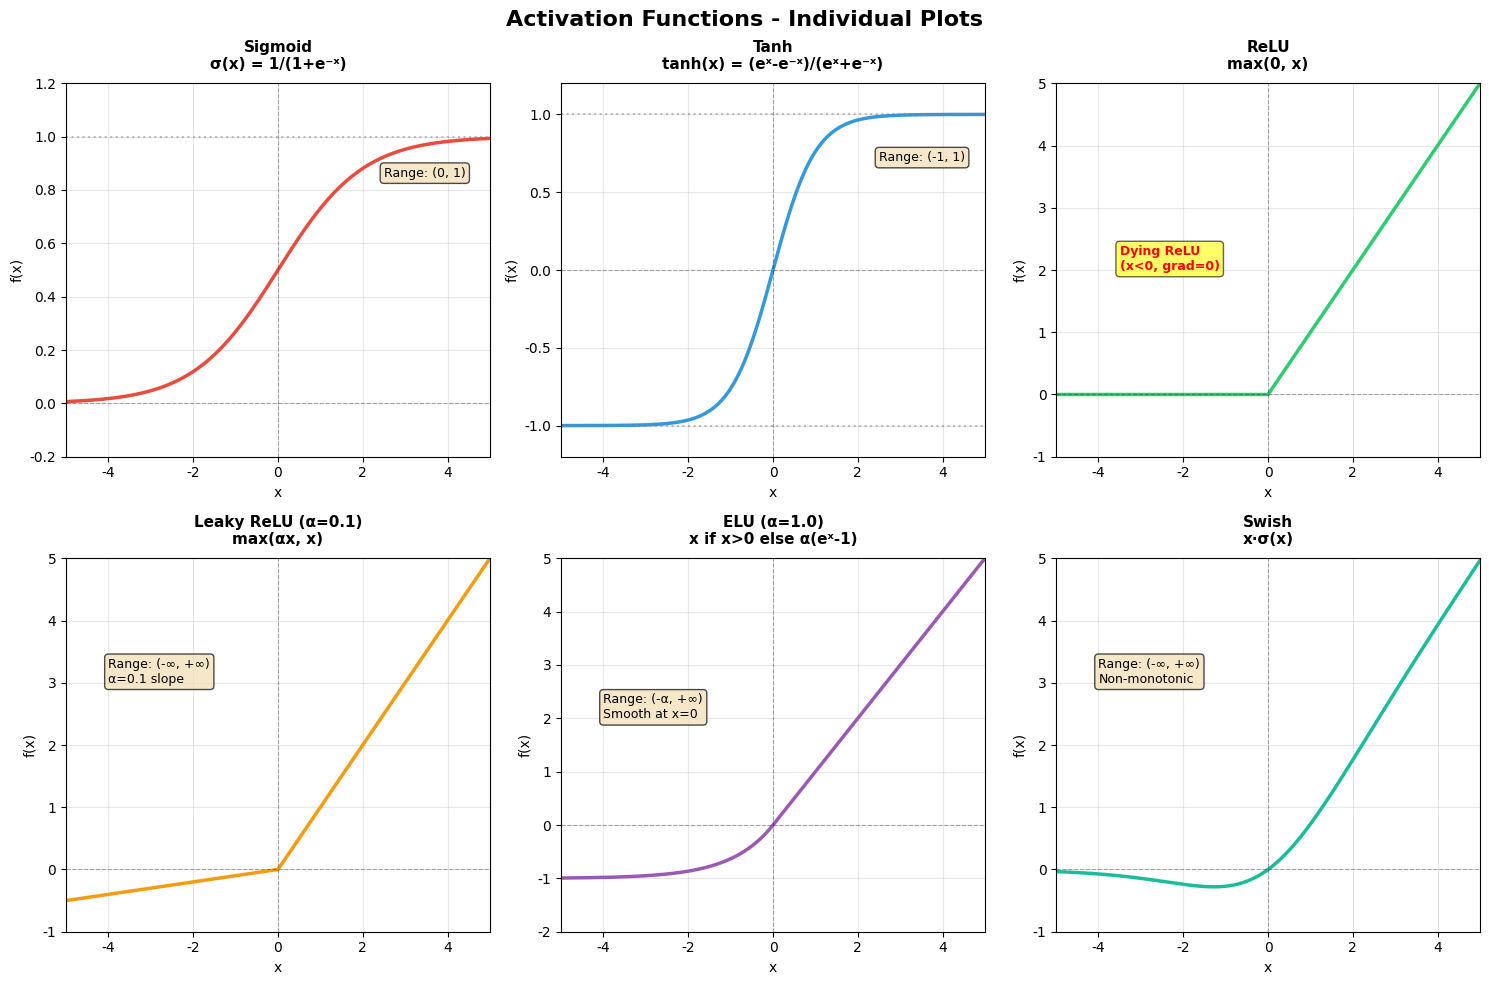

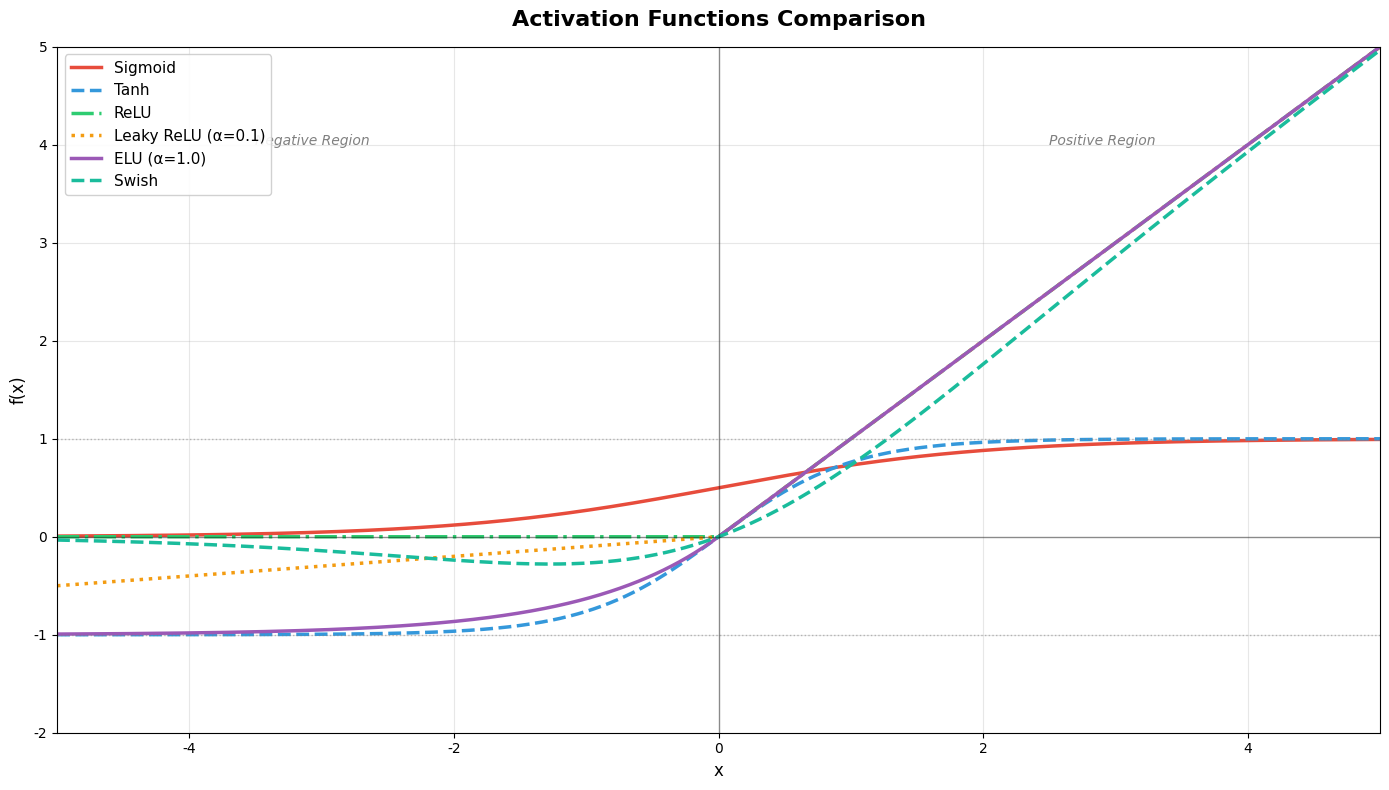

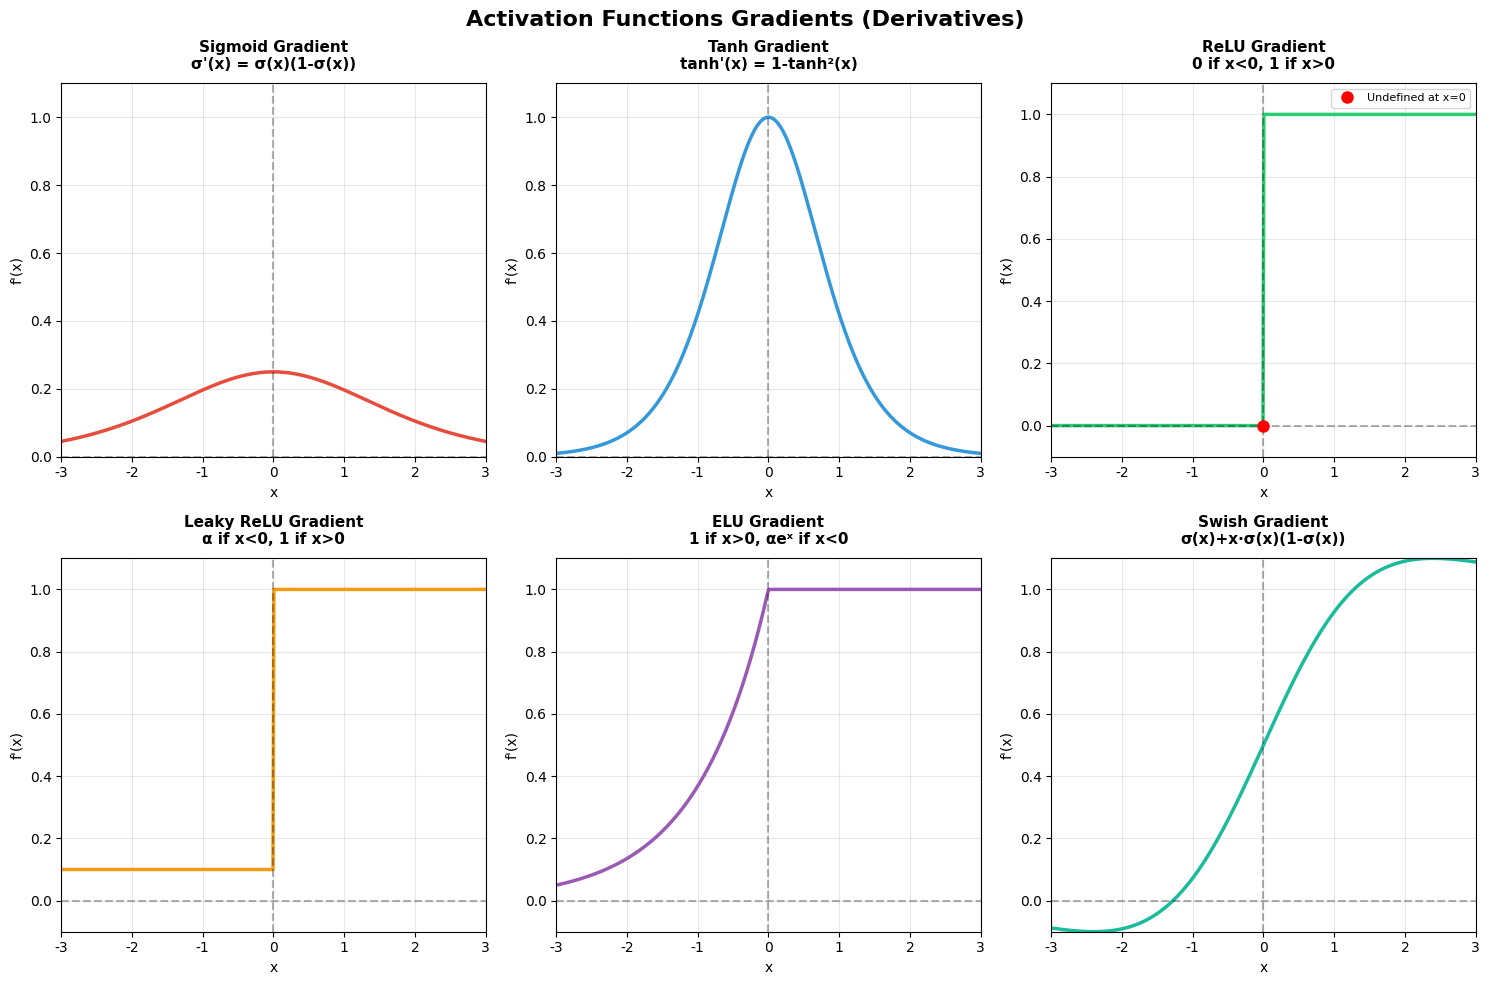

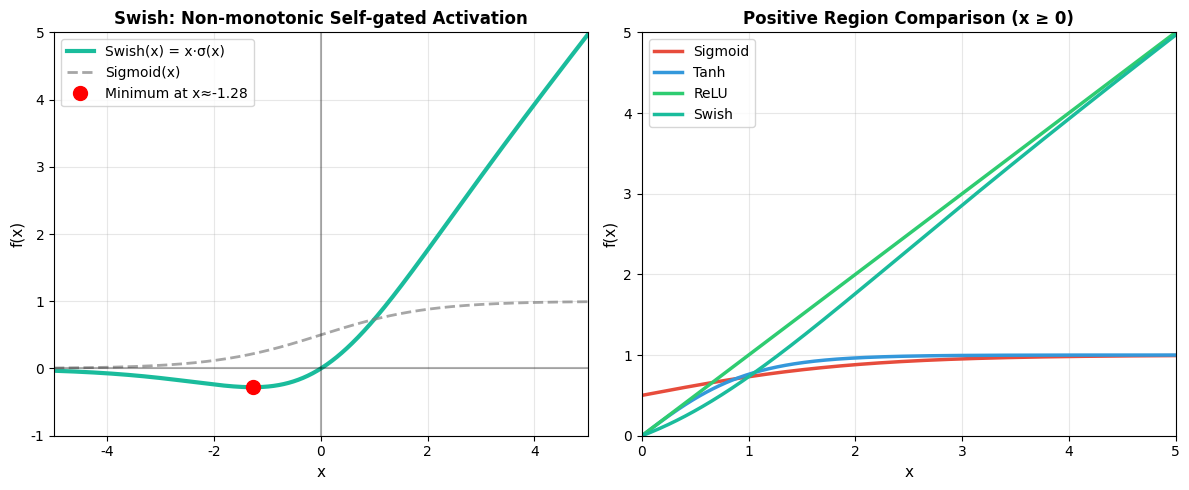

所有图形已生成完成！

生成的文件：
1. activation_functions_individual.png - 单独展示
2. activation_functions_comparison.png - 综合对比
3. activation_gradients.png - 梯度对比
4. activation_special_analysis.png - 特殊分析


In [1]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import numpy as np

# 设置中文字体支持
plt.rcParams['font.sans-serif'] = ['DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

# 定义输入范围
x = torch.linspace(-5, 5, 1000)

# ==================== 激活函数定义 ====================

def sigmoid(x):
    """Sigmoid: σ(x) = 1 / (1 + e^(-x))"""
    return 1 / (1 + torch.exp(-x))

def tanh(x):
    """Tanh: (e^x - e^(-x)) / (e^x + e^(-x))"""
    return torch.tanh(x)

def relu(x):
    """ReLU: max(0, x)"""
    return torch.maximum(torch.zeros_like(x), x)

def leaky_relu(x, alpha=0.01):
    """Leaky ReLU: max(αx, x)"""
    return torch.where(x > 0, x, alpha * x)

def elu(x, alpha=1.0):
    """ELU: x if x > 0 else α(e^x - 1)"""
    return torch.where(x > 0, x, alpha * (torch.exp(x) - 1))

def swish(x):
    """Swish: x * σ(x)"""
    return x * sigmoid(x)

# ==================== 计算所有激活值 ====================

y_sigmoid = sigmoid(x)
y_tanh = tanh(x)
y_relu = relu(x)
y_leaky_relu = leaky_relu(x, 0.1)  # 使用0.1便于观察
y_elu = elu(x, 1.0)
y_swish = swish(x)

# 转换为numpy用于绘图
x_np = x.numpy()
y_sigmoid_np = y_sigmoid.numpy()
y_tanh_np = y_tanh.numpy()
y_relu_np = y_relu.numpy()
y_leaky_relu_np = y_leaky_relu.numpy()
y_elu_np = y_elu.numpy()
y_swish_np = y_swish.numpy()

# ==================== 图1: 单独展示每个激活函数 ====================

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('Activation Functions - Individual Plots', fontsize=16, fontweight='bold')

functions = [
    ('Sigmoid\nσ(x) = 1/(1+e⁻ˣ)', y_sigmoid_np, '#E74C3C', '(0, 1)'),
    ('Tanh\ntanh(x) = (eˣ-e⁻ˣ)/(eˣ+e⁻ˣ)', y_tanh_np, '#3498DB', '(-1, 1)'),
    ('ReLU\nmax(0, x)', y_relu_np, '#2ECC71', '[0, +∞)'),
    ('Leaky ReLU (α=0.1)\nmax(αx, x)', y_leaky_relu_np, '#F39C12', '(-∞, +∞)'),
    ('ELU (α=1.0)\nx if x>0 else α(eˣ-1)', y_elu_np, '#9B59B6', '(-α, +∞)'),
    ('Swish\nx·σ(x)', y_swish_np, '#1ABC9C', '(-∞, +∞)'),
]

positions = [(0, 0), (0, 1), (0, 2), (1, 0), (1, 1), (1, 2)]

for (name, y, color, range_str), (row, col) in zip(functions, positions):
    ax = axes[row, col]
    
    # 绘制激活函数曲线
    ax.plot(x_np, y, color=color, linewidth=2.5, label=name.split('\n')[0])
    
    # 绘制参考线
    ax.axhline(y=0, color='black', linestyle='--', alpha=0.3, linewidth=0.8)
    ax.axvline(x=0, color='black', linestyle='--', alpha=0.3, linewidth=0.8)
    
    # 添加 y=1 和 y=-1 参考线（对于sigmoid和tanh）
    if 'Sigmoid' in name:
        ax.axhline(y=1, color='gray', linestyle=':', alpha=0.5)
    elif 'Tanh' in name:
        ax.axhline(y=1, color='gray', linestyle=':', alpha=0.5)
        ax.axhline(y=-1, color='gray', linestyle=':', alpha=0.5)
    
    # 设置标题和标签
    ax.set_title(name, fontsize=11, fontweight='bold', pad=10)
    ax.set_xlabel('x', fontsize=10)
    ax.set_ylabel('f(x)', fontsize=10)
    ax.grid(True, alpha=0.3)
    ax.set_xlim(-5, 5)
    
    # 根据函数调整y轴范围
    if 'Sigmoid' in name:
        ax.set_ylim(-0.2, 1.2)
        ax.annotate(f'Range: {range_str}', xy=(2.5, 0.85), fontsize=9, 
                   bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.7))
    elif 'Tanh' in name:
        ax.set_ylim(-1.2, 1.2)
        ax.annotate(f'Range: {range_str}', xy=(2.5, 0.7), fontsize=9,
                   bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.7))
    elif 'ReLU' in name and 'Leaky' not in name:
        ax.set_ylim(-1, 5)
        ax.annotate('Dying ReLU\n(x<0, grad=0)', xy=(-3.5, 2), fontsize=9, 
                   color='red', fontweight='bold',
                   bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.6))
    elif 'Leaky' in name:
        ax.set_ylim(-1, 5)
        ax.annotate(f'Range: {range_str}\nα=0.1 slope', xy=(-4, 3), fontsize=9,
                   bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.7))
    elif 'ELU' in name:
        ax.set_ylim(-2, 5)
        ax.annotate(f'Range: {range_str}\nSmooth at x=0', xy=(-4, 2), fontsize=9,
                   bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.7))
    else:  # Swish
        ax.set_ylim(-1, 5)
        ax.annotate(f'Range: {range_str}\nNon-monotonic', xy=(-4, 3), fontsize=9,
                   bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.7))

plt.tight_layout()
plt.savefig("activation_functions_individual.png", dpi=150, bbox_inches="tight", facecolor="white")
plt.show()

# ==================== 图2: 所有激活函数对比 ====================

fig, ax = plt.subplots(figsize=(14, 8))

# 绘制所有曲线
ax.plot(x_np, y_sigmoid_np, color='#E74C3C', linewidth=2.5, label='Sigmoid', linestyle='-')
ax.plot(x_np, y_tanh_np, color='#3498DB', linewidth=2.5, label='Tanh', linestyle='--')
ax.plot(x_np, y_relu_np, color='#2ECC71', linewidth=2.5, label='ReLU', linestyle='-.')
ax.plot(x_np, y_leaky_relu_np, color='#F39C12', linewidth=2.5, label='Leaky ReLU (α=0.1)', linestyle=':')
ax.plot(x_np, y_elu_np, color='#9B59B6', linewidth=2.5, label='ELU (α=1.0)', linestyle='-')
ax.plot(x_np, y_swish_np, color='#1ABC9C', linewidth=2.5, label='Swish', linestyle='--')

# 添加参考线
ax.axhline(y=0, color='black', linestyle='-', alpha=0.4, linewidth=1)
ax.axvline(x=0, color='black', linestyle='-', alpha=0.4, linewidth=1)
ax.axhline(y=1, color='gray', linestyle=':', alpha=0.5, linewidth=1)
ax.axhline(y=-1, color='gray', linestyle=':', alpha=0.5, linewidth=1)

ax.set_title('Activation Functions Comparison', fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('x', fontsize=12)
ax.set_ylabel('f(x)', fontsize=12)
ax.legend(loc='upper left', fontsize=11, framealpha=0.9)
ax.grid(True, alpha=0.3)
ax.set_xlim(-5, 5)
ax.set_ylim(-2, 5)

# 添加区域标注
ax.annotate('Negative Region', xy=(-3.5, 4), fontsize=10, color='gray', style='italic')
ax.annotate('Positive Region', xy=(2.5, 4), fontsize=10, color='gray', style='italic')

plt.tight_layout()
plt.savefig("activation_functions_comparison.png", dpi=150, bbox_inches="tight", facecolor="white")
plt.show()

# ==================== 图3: 导数（梯度）对比 ====================

# 计算导数
x_grad = torch.linspace(-3, 3, 500, requires_grad=True)

def compute_gradient(func, x):
    y = func(x)
    grad = torch.autograd.grad(y.sum(), x, create_graph=False)[0]
    return grad.detach().numpy()

# 计算各函数的梯度
grad_sigmoid = compute_gradient(sigmoid, x_grad)
grad_tanh = compute_gradient(tanh, x_grad)
grad_relu = compute_gradient(lambda x: torch.relu(x), x_grad)
grad_leaky_relu = compute_gradient(lambda x: leaky_relu(x, 0.1), x_grad)
grad_elu = compute_gradient(lambda x: elu(x, 1.0), x_grad)
grad_swish = compute_gradient(swish, x_grad)

x_grad_np = x_grad.detach().numpy()

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('Activation Functions Gradients (Derivatives)', fontsize=16, fontweight='bold')

gradients = [
    ('Sigmoid Gradient\nσ\'(x) = σ(x)(1-σ(x))', grad_sigmoid, '#E74C3C', 0, 1.1),
    ('Tanh Gradient\ntanh\'(x) = 1-tanh²(x)', grad_tanh, '#3498DB', 0, 1.1),
    ('ReLU Gradient\n0 if x<0, 1 if x>0', grad_relu, '#2ECC71', -0.1, 1.1),
    ('Leaky ReLU Gradient\nα if x<0, 1 if x>0', grad_leaky_relu, '#F39C12', -0.1, 1.1),
    ('ELU Gradient\n1 if x>0, αeˣ if x<0', grad_elu, '#9B59B6', -0.1, 1.1),
    ('Swish Gradient\nσ(x)+x·σ(x)(1-σ(x))', grad_swish, '#1ABC9C', -0.1, 1.1),
]

for (name, grad, color, ymin, ymax), (row, col) in zip(gradients, positions):
    ax = axes[row, col]
    
    ax.plot(x_grad_np, grad, color=color, linewidth=2.5)
    ax.axhline(y=0, color='black', linestyle='--', alpha=0.3)
    ax.axvline(x=0, color='black', linestyle='--', alpha=0.3)
    
    # 标注特殊点
    if 'ReLU' in name and 'Leaky' not in name:
        ax.plot(0, 0, 'ro', markersize=8, label='Undefined at x=0')
        ax.legend(loc='best', fontsize=8)
    
    ax.set_title(name, fontsize=11, fontweight='bold', pad=10)
    ax.set_xlabel('x', fontsize=10)
    ax.set_ylabel('f\'(x)', fontsize=10)
    ax.grid(True, alpha=0.3)
    ax.set_xlim(-3, 3)
    ax.set_ylim(ymin, ymax)

plt.tight_layout()
plt.savefig("activation_gradients.png", dpi=150, bbox_inches="tight", facecolor="white")
plt.show()

# ==================== 图4: 3D 可视化（Swish的非单调性） ====================

from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(12, 5))

# 左图：Swish 的详细分析
ax1 = fig.add_subplot(121)
ax1.plot(x_np, y_swish_np, color='#1ABC9C', linewidth=3, label='Swish(x) = x·σ(x)')
ax1.plot(x_np, y_sigmoid_np, color='gray', linewidth=2, linestyle='--', alpha=0.7, label='Sigmoid(x)')
ax1.axhline(y=0, color='black', linestyle='-', alpha=0.3)
ax1.axvline(x=0, color='black', linestyle='-', alpha=0.3)

# 标记最小值点（Swish在x≈-1.28处有最小值）
min_idx = np.argmin(y_swish_np)
min_x = x_np[min_idx]
min_y = y_swish_np[min_idx]
ax1.plot(min_x, min_y, 'ro', markersize=10, label=f'Minimum at x≈{min_x:.2f}')

ax1.set_title('Swish: Non-monotonic Self-gated Activation', fontsize=12, fontweight='bold')
ax1.set_xlabel('x', fontsize=11)
ax1.set_ylabel('f(x)', fontsize=11)
ax1.legend(loc='upper left', fontsize=10)
ax1.grid(True, alpha=0.3)
ax1.set_xlim(-5, 5)
ax1.set_ylim(-1, 5)

# 右图：所有激活函数在正区间的行为
ax2 = fig.add_subplot(122)
x_pos = x_np[x_np >= 0]
ax2.plot(x_pos, y_sigmoid_np[x_np >= 0], color='#E74C3C', linewidth=2.5, label='Sigmoid')
ax2.plot(x_pos, y_tanh_np[x_np >= 0], color='#3498DB', linewidth=2.5, label='Tanh')
ax2.plot(x_pos, y_relu_np[x_np >= 0], color='#2ECC71', linewidth=2.5, label='ReLU')
ax2.plot(x_pos, y_swish_np[x_np >= 0], color='#1ABC9C', linewidth=2.5, label='Swish')

ax2.set_title('Positive Region Comparison (x ≥ 0)', fontsize=12, fontweight='bold')
ax2.set_xlabel('x', fontsize=11)
ax2.set_ylabel('f(x)', fontsize=11)
ax2.legend(loc='best', fontsize=10)
ax2.grid(True, alpha=0.3)
ax2.set_xlim(0, 5)
ax2.set_ylim(0, 5)

plt.tight_layout()
plt.savefig("activation_special_analysis.png", dpi=150, bbox_inches="tight", facecolor="white")
plt.show()

print("所有图形已生成完成！")
print("\n生成的文件：")
print("1. activation_functions_individual.png - 单独展示")
print("2. activation_functions_comparison.png - 综合对比")
print("3. activation_gradients.png - 梯度对比")
print("4. activation_special_analysis.png - 特殊分析")